In [1]:
# --- BƯỚC 1: NẠP THƯ VIỆN ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# --- BƯỚC 2: NẠP & XỬ LÝ DỮ LIỆU ---
# Hãy đảm bảo file train.csv nằm ở đúng đường dẫn này
df = pd.read_csv('../data/raw/train.csv')

# Chuyển đổi định dạng thời gian
df['datetime'] = pd.to_datetime(df['datetime'])
df['hour'] = df['datetime'].dt.hour
df['month'] = df['datetime'].dt.month

print("Dữ liệu đã sẵn sàng!")

Dữ liệu đã sẵn sàng!


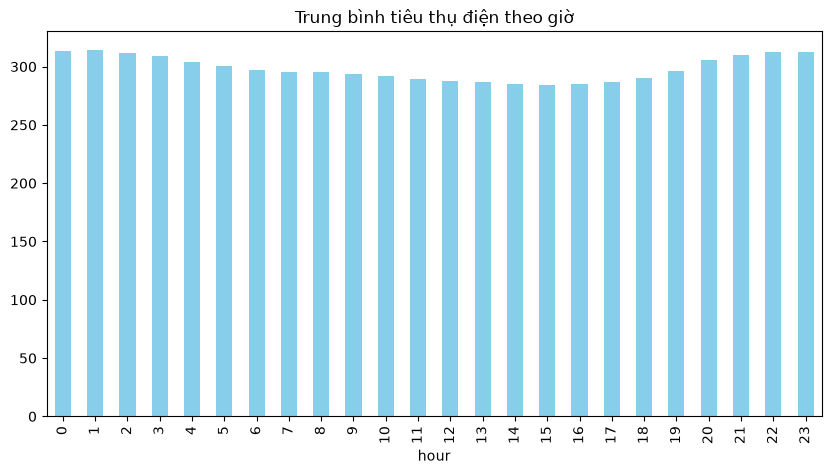

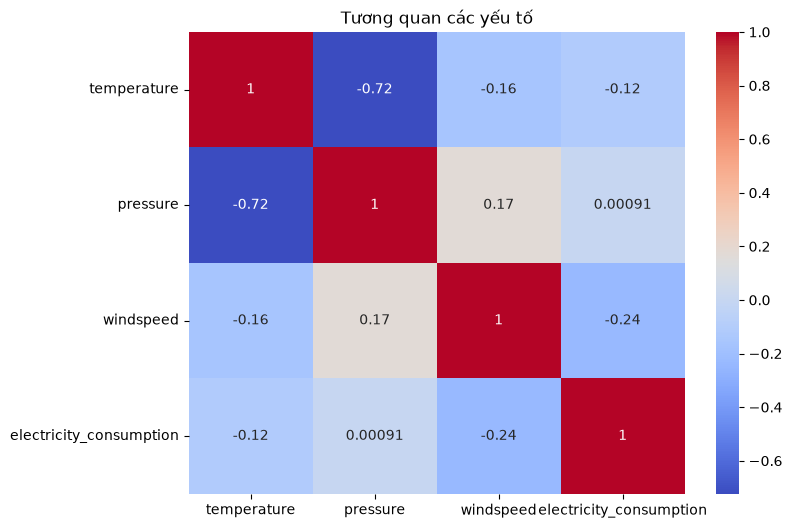

In [3]:
# --- BƯỚC 3: PHÂN TÍCH DỮ LIỆU (EDA) ---
# Biểu đồ tiêu thụ điện theo giờ
plt.figure(figsize=(10, 5))
df.groupby('hour')['electricity_consumption'].mean().plot(kind='bar', color='skyblue')
plt.title('Trung bình tiêu thụ điện theo giờ')
plt.show()

# Biểu đồ tương quan (Heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(df[['temperature', 'pressure', 'windspeed', 'electricity_consumption']].corr(), 
            annot=True, cmap='coolwarm')
plt.title('Tương quan các yếu tố')
plt.show()

In [4]:
# --- BƯỚC 4: DỰ BÁO (MACHINE LEARNING) ---
X = df[['temperature', 'hour', 'month']] 
y = df['electricity_consumption']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f'Độ chính xác (R2 Score): {r2_score(y_test, y_pred):.2f}')
print(f'Sai số (MSE): {mean_squared_error(y_test, y_pred):.2f}')

Độ chính xác (R2 Score): 0.01
Sai số (MSE): 11413.59
